# Compare LLMs to baseline in no-battery variant

Simulation variant (resulting from grid search): no-battery, WaitBeforeEat: 5, NearbyBirdsToEat: 2, birdCohesion: 0.5

Baselines: rule-based random, rule-based full nearest, rule-based full nearest 10 steps

LLMs: gpt-4o-mini-2024-07-18, claude-3-5-haiku-20241022, gemini-1.5-flash, gpt-4o, openai-o1-mini, claude-3-5-sonnet

Prompt: drones (for each drone, output a group)

Prompt goals: none, full_protection, threat_level_2, threat_level_3 (= description of "rule-based full nearest"), sd1 (detailed description of simulation)

History: none, 5 adaptations

In [31]:
!ls -l  # check that we are in the correct directory

total 23
-rw-r----- 1 root users 113 Nov  5 14:04 10steps.yaml
-rw-r----- 1 root users 109 Nov 22 08:50 5steps.yaml
-rw-r----- 1 root users  91 Nov 15 09:49 battery_and_charging_rl.yaml
-rw-r----- 1 root users 270 Nov 25 10:45 config_auto_charging_only.yaml
-rw-r----- 1 root users 230 Nov 25 10:45 config_auto_charging.yaml
-rw-r----- 1 root users  35 Nov 25 10:45 config_battery_and_charging.yaml
-rw-r----- 1 root users 142 Nov 25 10:45 config_no_battery.yaml
-rw-r----- 1 root users 162 Nov 25 10:45 default_old.yaml
-rw-r----- 1 root users 652 Nov 25 10:45 default.yaml
-rw-r----- 1 root users 401 Jan  2 12:18 drones.yaml
-rw-r----- 1 root users 250 Nov 22 08:50 goal_charging.yaml
-rw-r----- 1 root users 426 Nov 22 08:50 goal_full_protection.yaml
-rw-r----- 1 root users 257 Nov 25 10:45 goal_threat_level2.yaml
-rw-r----- 1 root users 564 Jan  9 09:36 goal_threat_level3_full_protection.yaml
-rw-r----- 1 root users 423 Jan  9 09:36 goal_threat_level3.yaml
-rw-r----- 1 root users 261 Nov 22

In [1]:
import subprocess
import os

def run(args, repeats=10, start=1):
    print(args)
    for repeat in range(repeats):
        print(f"  Run #{repeat + start}/{repeats + start - 1}")
        run = ["python", "main.py", *args, "-s", str(repeat + start), "-e", str(repeat + start)]
        # if repeat % 10 == 0:
        #     run.append("--animation")
        
        # disable TF errors
        env = dict(os.environ, TF_CPP_MIN_LOG_LEVEL="3")

        result = subprocess.run(run, capture_output=True, env=env)
        stdout = result.stdout.decode("utf-8")
        stderr = result.stderr.decode("utf-8")

        damage = stdout.partition("damage: ")[2].partition("\n")[0]
        print(f"    Damage: {damage}")

        #print(stdout.partition("Simulation done\n")[2])
        # print(stdout)
        if stderr:
            print(stderr)

In [3]:
grid_params = {
    "llm": ["llm_gpt4omini", "llm_claude35haiku", "llm_gemini15flash"],
    # "goal": [None, "goal_full_protection", "goal_threat_level2"],
    "goal": ["goal_threat_level3", "goal_threat_level3_full_protection"],
    "history": [None, "llm_history_5"],
}

In [33]:
grid_params_2 = {
    "llm": ["llm_gpt4o", "llm_o1mini", "llm_claude35sonnet"],
    "goal": [None, "goal_threat_level3"],
    "history": [None, "llm_history_5"],
}

In [23]:
grid_params_3 = {
    "llm": ["llm_gpt4omini", "llm_claude35haiku", "llm_gemini15flash", "llm_gpt4o"],
    "goal": ["simulation_description_1"],
    "history": [None, "llm_history_5"],
}

In [25]:
import itertools

grid = list(itertools.product(*grid_params.values()))
print(len(grid))

8


In [27]:
for i, params in enumerate(grid, start=1):
    print(f"{i}/{len(grid)}")

    args = ["configs/default.yaml", "configs/config_no_battery.yaml", "configs/drones.yaml"]
    
    for param in params:
        if param is not None:
            args.append(f"configs/{param}.yaml")

    args.append("configs/no_battery_llm.yaml")
    args.append("../configs/deepnote_0102.yaml")  # this is just to save the results to a specific folder, it can be safely removed

    # for config_file in args:
    #     assert os.path.exists(config_file), f"File {config_file} does not exist"
    
    run(args, repeats=5)
    # run(args, repeats=5, start=6)

1/8
['configs/default.yaml', 'configs/config_no_battery.yaml', 'configs/drones.yaml', 'configs/llm_gpt4omini.yaml', 'configs/simulation_description_1.yaml', 'configs/no_battery_llm.yaml', '../configs/deepnote_0102.yaml']
  Run #0
    Damage: 188
  Run #1
    Damage: 164
  Run #2
    Damage: 206
  Run #3
    Damage: 144
  Run #4
    Damage: 217
2/8
['configs/default.yaml', 'configs/config_no_battery.yaml', 'configs/drones.yaml', 'configs/llm_gpt4omini.yaml', 'configs/simulation_description_1.yaml', 'configs/llm_history_5.yaml', 'configs/no_battery_llm.yaml', '../configs/deepnote_0102.yaml']
  Run #0
    Damage: 238
  Run #1
    Damage: 203
  Run #2
    Damage: 203
  Run #3
    Damage: 
Traceback (most recent call last):
  File "/datasets/_deepnote_work/llm_adaptation/main.py", line 59, in <module>
    simulation.run_simulation(300)
  File "/datasets/_deepnote_work/llm_adaptation/simulation.py", line 59, in run_simulation
    self.simulation_step(step)
  File "/datasets/_deepnote_work/ll

In [3]:
# re-run failed runs (Gemini 500 errors)
# common_args = ["configs/default.yaml", "configs/config_no_battery.yaml", "configs/drones.yaml", "configs/llm_gemini15flash.yaml"]
# common_args_end = ["configs/no_battery_llm.yaml", "../configs/deepnote_0102.yaml"]

# run(common_args + [] + common_args_end, repeats=1, start=5)
# run(common_args + ["configs/llm_history_5.yaml"] + common_args_end, repeats=1, start=1)
# run(common_args + ["configs/llm_history_5.yaml"] + common_args_end, repeats=1, start=7)
# run(common_args + ["configs/llm_history_5.yaml"] + common_args_end, repeats=1, start=8)
# run(common_args + ["configs/goal_threat_level2.yaml"] + common_args_end, repeats=1, start=2)
# run(common_args + ["configs/goal_threat_level2.yaml"] + common_args_end, repeats=1, start=4)
# run(common_args + ["configs/goal_threat_level2.yaml", "configs/llm_history_5.yaml"] + common_args_end, repeats=1, start=4)
# run(common_args + ["configs/goal_threat_level2.yaml", "configs/llm_history_5.yaml"] + common_args_end, repeats=1, start=5)
# run(['configs/default.yaml', 'configs/config_no_battery.yaml', 'configs/drones.yaml', 'configs/llm_gpt4omini.yaml', 'configs/simulation_description_1.yaml', 'configs/llm_history_5.yaml', 'configs/no_battery_llm.yaml', '../configs/deepnote_0102.yaml'], repeats=1, start=4)

['configs/default.yaml', 'configs/config_no_battery.yaml', 'configs/drones.yaml', 'configs/llm_gpt4omini.yaml', 'configs/simulation_description_1.yaml', 'configs/llm_history_5.yaml', 'configs/no_battery_llm.yaml', '../configs/deepnote_0102.yaml']
  Run #4/4
    Damage: 166


In [48]:
# run another baseline (which was not run during grid search)
args = ["configs/default.yaml", "configs/config_no_battery.yaml", "configs/rule_based_full_nearest.yaml", "configs/10steps.yaml", "../configs/deepnote_0102.yaml"]
run(args, repeats=10)

['configs/default.yaml', 'configs/config_no_battery.yaml', 'configs/rule_based_full_nearest.yaml', 'configs/10steps.yaml', '../configs/deepnote_0102.yaml']
  Run #0
    Damage: 25
  Run #1
    Damage: 25
  Run #2
    Damage: 14
  Run #3
    Damage: 6
  Run #4
    Damage: 6
  Run #5
    Damage: 7
  Run #6
    Damage: 31
  Run #7
    Damage: 14
  Run #8
    Damage: 8
  Run #9
    Damage: 12


## Results - Damage

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
baselines = {
    "rule_based_random": "../logs/grid_search_birds/birdCohesion_0.5,bird.WaitBeforeEat_5,bird.NearbyBirdsToEat_2,/rule_based_random",
    "rule_based_full_nearest": "../logs/grid_search_birds/birdCohesion_0.5,bird.WaitBeforeEat_5,bird.NearbyBirdsToEat_2,/rule_based_full_nearest",
    "rule_based_full_nearest_10": "../0102/logs/no_battery/rule_based_full_nearest_10steps",
}

In [9]:
results_folder = Path("../0102/logs/no_battery")

results_files = sorted(results_folder.glob("*/*.csv"))
print(len(results_files), "files found")

387 files found


In [7]:
summary = pd.DataFrame(columns=["llm", "params", "damage"])

In [8]:
for baseline, folder in baselines.items():
    path = Path(folder)
    files = sorted(path.glob("*.csv"))

    for file in files:
        try:
            data = pd.read_csv(file)
            damage = data.iloc[299]["damage"]  # 300th step
            
            llm = "baseline"
            params = baseline

            summary.loc[len(summary)] = [llm, params, damage]
        except pd.errors.EmptyDataError:
            print("Skipping empty file", file)
        except IndexError:
            print("Index error in file", file)

In [9]:
for file in results_files:
    try:
        name = file.stem
        if "drones" not in name:
            continue

        data = pd.read_csv(file)
        damage = data.iloc[299]["damage"]  # 300th step
                
        parts = name[name.find("drones"):].split("_")
        llm = parts[1]
        params = []
        for param in ["full_protection", "threat_level2", "threat_level3", "sd1", "history5"]:
            if param in name:
                params.append(param)
        if params == []:
            params = ["default"]
        params = ",\n".join(params)
        
        summary.loc[len(summary)] = [llm, params, damage]
    except pd.errors.EmptyDataError:
        print("Skipping empty file", file)
    except IndexError:
        print("Index error in file", file)

summary.to_csv(results_folder / "summary.csv", index=False)

In [10]:
summary = pd.read_csv(results_folder / "summary.csv")

In [11]:
palette = {
    "baseline": "tab:gray",
    "gpt4omini": "tab:red",
    "claude35haiku": "tab:blue",
    "gemini15flash": "tab:green",
    "gpt4o": "tab:orange",
    "claude35sonnet": "tab:cyan",
    "o1mini": "tab:pink",
}

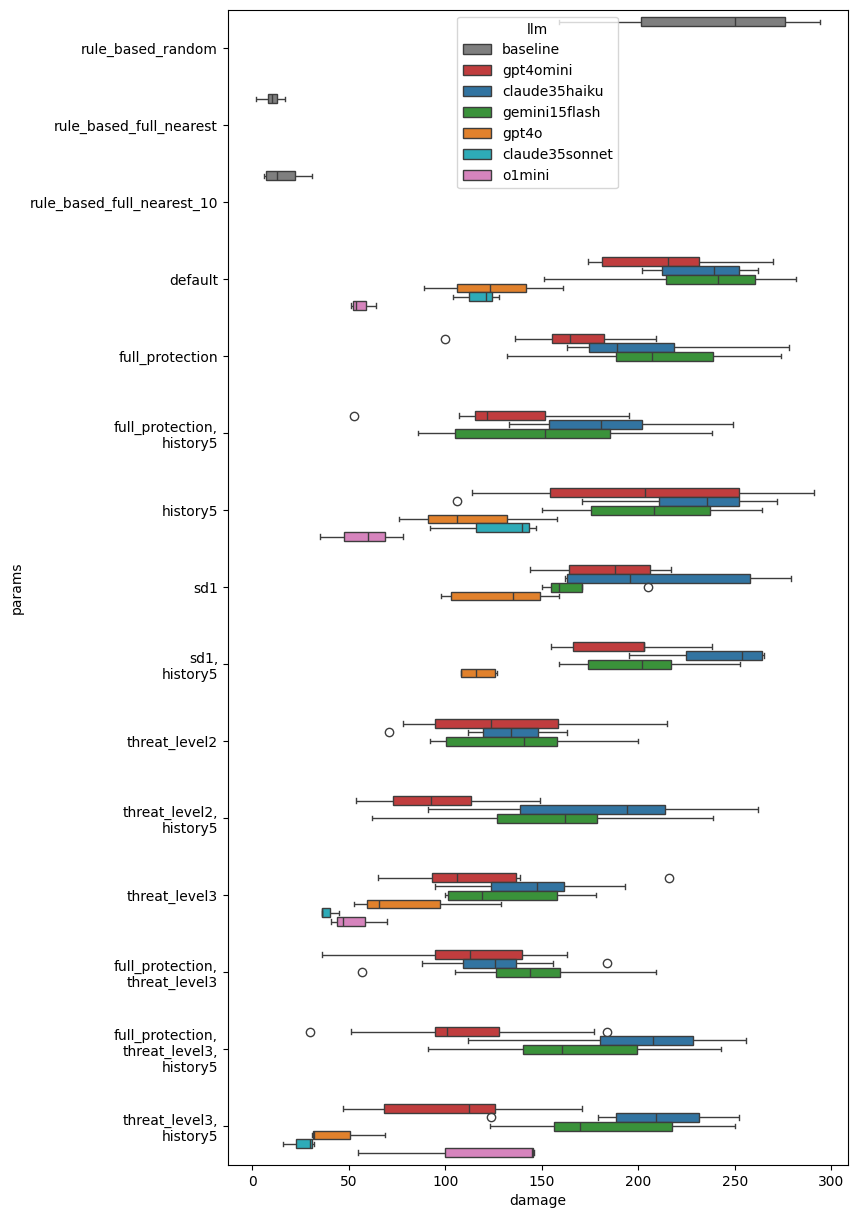

In [12]:
fig, ax = plt.subplots(figsize=(8, 15))
sns.boxplot(x="damage", y="params", hue="llm", data=summary, ax=ax, palette=palette, hue_order=palette.keys())
plt.show()

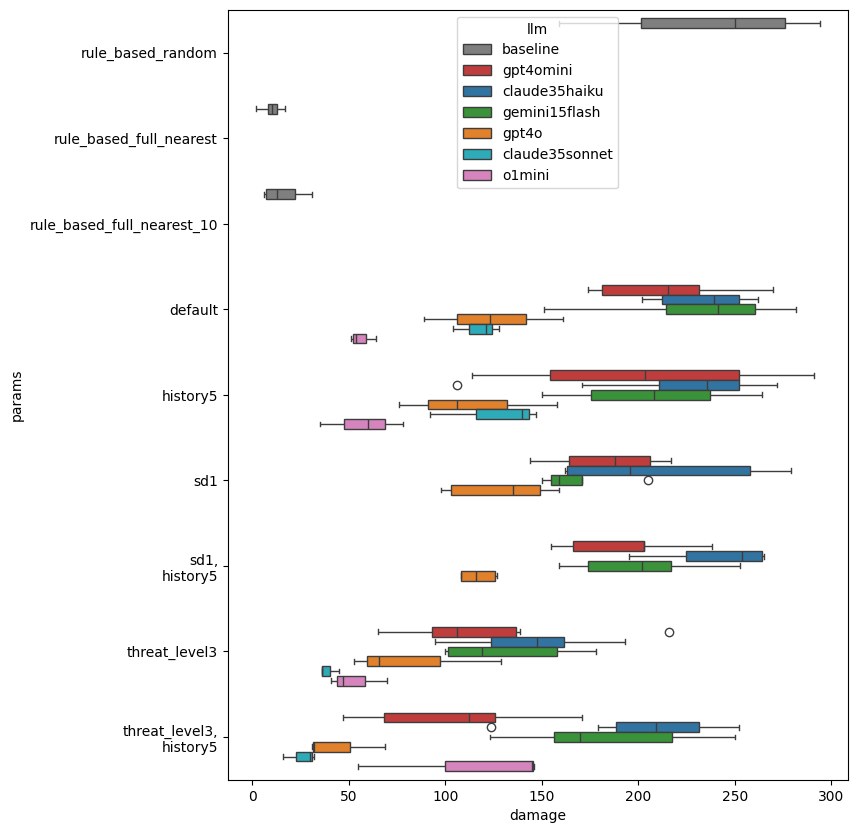

In [13]:
rows = ["default", "threat_level3", "history5", "threat_level3,\nhistory5", "sd1", "sd1,\nhistory5", *baselines.keys()]
fig, ax = plt.subplots(figsize=(8, 10))
sns.boxplot(x="damage", y="params", hue="llm", data=summary[summary["params"].isin(rows)], ax=ax, palette=palette, hue_order=palette.keys())
plt.show()

## Results - drone assignments

In [11]:
drone_assignments = pd.DataFrame(columns=["llm", "params", "new_target", "same_target", "invalid_row", "unknown_group", "filename"])

In [12]:
for baseline, folder in baselines.items():
    path = Path(folder)
    files = sorted(path.glob("*.ansi"))

    for file in files:
        try:
            with open(file, 'r') as f:
                content = f.read()
                new_targets = content.count("Assigning new target")
                same_targets = content.count("Assigning same target")
                invalid_rows = content.count("Invalid row")
                unknown_groups = content.count("Unknown group")
            
            llm = "baseline"
            params = baseline
            name = file.stem

            drone_assignments.loc[len(drone_assignments)] = [llm, params, new_targets, same_targets, invalid_rows, unknown_groups, name]
        except FileNotFoundError:
            print("File not found: ", file)

In [13]:
log_files = sorted(results_folder.glob("*/*.ansi"))

ignored_invalid_rows = [
    "Invalid row (not enough values to unpack (expected 2, got 1)): '```'",
    "Invalid row (not enough values to unpack (expected 2, got 1)): ''",
    "Invalid row ('- Drone_",
]

for file in log_files:
    try:
        name = file.stem
        if "drones" not in name:
            continue

        with open(file, 'r') as f:
            content = f.read()
            new_targets = content.count("Assigning new target")
            same_targets = content.count("Assigning same target")
            invalid_rows = content.count("Invalid row")
            for ignored in ignored_invalid_rows:
                invalid_rows -= content.count(ignored)
            unknown_groups = content.count("Unknown group")

        parts = name[name.find("drones"):].split("_")
        llm = parts[1]
        params = []
        for param in ["full_protection", "threat_level2", "threat_level3", "sd1", "history5"]:
            if param in name:
                params.append(param)
        if params == []:
            params = ["default"]
        params = ",\n".join(params)
        
        drone_assignments.loc[len(drone_assignments)] = [llm, params, new_targets, same_targets, invalid_rows, unknown_groups, name]
    except FileNotFoundError:
            print("File not found: ", file)

drone_assignments.to_csv(results_folder / "drone_assignments.csv", index=False)

In [14]:
drone_assignments["total_assignments"] = drone_assignments["same_target"] + drone_assignments["new_target"]

# rule_based_full_nearest adapts on every step, but LLMs only each 10th step
drone_assignments.loc[drone_assignments['params'] == 'rule_based_full_nearest', ['new_target', 'same_target', 'total_assignments']] /= 10

/tmp/ipykernel_113/3424976718.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[14.1 17.6 15.9 17.6 19.4 19.3 19.5 18.2 13.3 23.7]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  drone_assignments.loc[drone_assignments['params'] == 'rule_based_full_nearest', ['new_target', 'same_target', 'total_assignments']] /= 10
/tmp/ipykernel_113/3424976718.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[225.9 222.4 224.1 222.4 220.6 220.7 220.5 221.8 226.7 216.3]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  drone_assignments.loc[drone_assignments['params'] == 'rule_based_full_nearest', ['new_target', 'same_target', 'total_assignments']] /= 10


In [18]:
drone_assignments

,llm,params,new_target,same_target,invalid_row,unknown_group,total_assignments
0,baseline,rule_based_random,8.0,0.0,0,0,8
1,baseline,rule_based_random,8.0,0.0,0,0,8
2,baseline,rule_based_random,8.0,0.0,0,0,8
3,baseline,rule_based_random,8.0,0.0,0,0,8
4,baseline,rule_based_random,8.0,0.0,0,0,8
...,...,...,...,...,...,...,...
402,o1mini,threat_level3,41.0,199.0,54,0,240
403,o1mini,threat_level3,45.0,187.0,62,0,232
404,o1mini,"threat_level3,\nhistory5",16.0,224.0,60,0,240
405,o1mini,"threat_level3,\nhistory5",7.0,233.0,60,0,240


In [15]:
# adaptation every 10 steps should total to 240 drone target assignments (30 adaptations x 8 drones)
# other values indicate a possible issue (missing drones in answers, ...)
drone_assignments[(drone_assignments['total_assignments'] != 240) & (drone_assignments['llm'] != 'baseline')]

,llm,params,new_target,same_target,invalid_row,unknown_group,filename,total_assignments
30,claude35haiku,default,62.0,180.0,7,0,001-2025-01-02-15-57-14-drones_claude35haiku,242
31,claude35haiku,default,46.0,193.0,1,1,002-2025-01-02-20-56-52-drones_claude35haiku,239
43,claude35haiku,full_protection,51.0,190.0,2,0,004-2025-01-02-21-39-09-drones_claude35haiku_f...,241
67,claude35haiku,history5,228.0,134.0,0,0,008-2025-01-03-15-19-32-drones_claude35haiku_h...,362
74,claude35haiku,sd1,56.0,185.0,1,0,005-2025-01-20-16-30-46-drones_claude35haiku_sd1,241
...,...,...,...,...,...,...,...,...
384,gpt4omini,"full_protection,\nthreat_level3,\nhistory5",23.0,208.0,5,1,010-2025-01-20-10-54-38-drones_gpt4omini_threa...,231
389,gpt4omini,"threat_level3,\nhistory5",31.0,201.0,0,0,005-2025-01-09-10-31-12-drones_gpt4omini_threa...,232
390,gpt4omini,"threat_level3,\nhistory5",28.0,211.0,0,1,006-2025-01-20-09-19-45-drones_gpt4omini_threa...,239
401,o1mini,threat_level3,38.0,186.0,0,0,001-2025-01-09-16-57-03-drones_o1mini_threat_l...,224


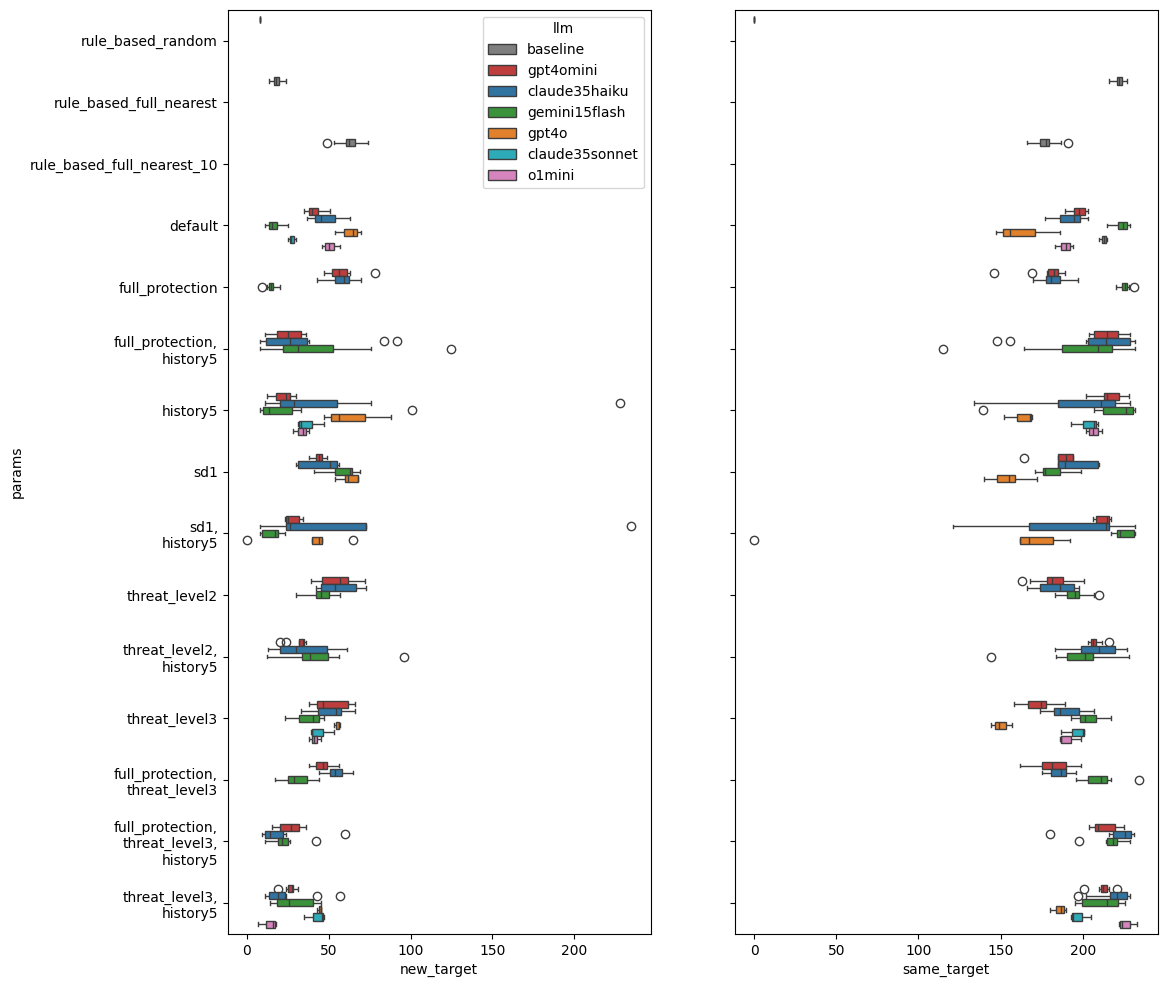

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 12))
sns.boxplot(x="new_target", y="params", hue="llm", data=drone_assignments, ax=axes[0], palette=palette, hue_order=palette.keys())
p = sns.boxplot(x="same_target", y="params", hue="llm", data=drone_assignments, ax=axes[1], palette=palette, hue_order=palette.keys(), legend=False)
p.set(yticklabels=[])
p.set(ylabel=None)
plt.show()

In [16]:
drone_assignments[(drone_assignments["invalid_row"] != 0) & (drone_assignments['llm'] != 'baseline')]

,llm,params,new_target,same_target,invalid_row,unknown_group,filename,total_assignments
30,claude35haiku,default,62.0,180.0,7,0,001-2025-01-02-15-57-14-drones_claude35haiku,242
31,claude35haiku,default,46.0,193.0,1,1,002-2025-01-02-20-56-52-drones_claude35haiku,239
32,claude35haiku,default,63.0,177.0,9,0,003-2025-01-02-20-59-45-drones_claude35haiku,240
33,claude35haiku,default,48.0,192.0,8,0,004-2025-01-02-21-02-37-drones_claude35haiku,240
34,claude35haiku,default,43.0,197.0,1,0,005-2025-01-02-21-05-31-drones_claude35haiku,240
...,...,...,...,...,...,...,...,...
372,gpt4omini,"full_protection,\nthreat_level3",46.0,162.0,2,0,008-2025-01-20-10-07-00-drones_gpt4omini_threa...,208
376,gpt4omini,"full_protection,\nthreat_level3,\nhistory5",19.0,221.0,3,0,002-2025-01-09-11-13-51-drones_gpt4omini_threa...,240
382,gpt4omini,"full_protection,\nthreat_level3,\nhistory5",29.0,211.0,19,0,008-2025-01-20-10-38-15-drones_gpt4omini_threa...,240
383,gpt4omini,"full_protection,\nthreat_level3,\nhistory5",35.0,205.0,1,0,009-2025-01-20-10-45-39-drones_gpt4omini_threa...,240


In [17]:
drone_assignments[(drone_assignments["unknown_group"] != 0) & (drone_assignments['llm'] != 'baseline')]

,llm,params,new_target,same_target,invalid_row,unknown_group,filename,total_assignments
31,claude35haiku,default,46.0,193.0,1,1,002-2025-01-02-20-56-52-drones_claude35haiku,239
83,claude35haiku,threat_level2,73.0,166.0,1,2,004-2025-01-02-22-16-07-drones_claude35haiku_t...,239
114,claude35haiku,"full_protection,\nthreat_level3",58.0,180.0,0,2,005-2025-01-09-12-22-11-drones_claude35haiku_t...,238
209,gemini15flash,threat_level2,45.0,194.0,0,1,007-2025-01-03-00-22-58-drones_gemini15flash_t...,239
265,gpt4o,default,65.0,156.0,0,1,003-2025-01-09-15-19-09-drones_gpt4o,221
269,gpt4o,sd1,62.0,159.0,0,1,001-2025-01-20-17-19-40-drones_gpt4o_sd1,221
277,gpt4o,"sd1,\nhistory5",44.0,182.0,0,1,004-2025-01-20-17-51-56-drones_gpt4o_sd1_history5,226
280,gpt4o,threat_level3,53.0,149.0,0,1,002-2025-01-09-15-44-04-drones_gpt4o_threat_le...,202
297,gpt4omini,full_protection,56.0,182.0,0,2,003-2025-01-02-18-53-25-drones_gpt4omini_full_...,238
317,gpt4omini,history5,22.0,208.0,1,10,003-2025-01-02-18-20-22-drones_gpt4omini_history5,230


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6dddcb2f-9a74-4511-ab27-8e86504a138c' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>